# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [1]:
intro_text = """
Под transfer learning я понимаю использование уже предобученной нейронной сети
для новой задачи классификации изображений. Идея состоит в том, что модель уже
успела выучить базовые визуальные признаки на большом датасете, например ImageNet:
границы, текстуры, формы объектов и другие полезные особенности изображений.

Это особенно полезно, когда у нас мало собственных размеченных данных,
потому что обучать глубокую сеть полностью с нуля в таком случае сложно:
модель может переобучиться или просто не успеть выучить хорошие признаки.

Если обучается только последний слой сети, то остальные слои остаются
замороженными и используются как готовый извлекатель признаков.
В этом случае обучение происходит быстрее и требует меньше вычислений,
но модель хуже адаптируется к особенностям новой задачи.

При полном дообучении сети изменяются веса всех слоёв,
поэтому модель может лучше подстроиться под конкретный датасет.
Однако такое обучение обычно требует больше времени,
аккуратного подбора learning rate и может привести к переобучению,
особенно на небольшом количестве данных.

Я ожидаю, что предобученная ResNet18 покажет более высокую точность,
чем похожая сеть, обученная полностью с нуля на небольшом подмножестве данных.
Также, скорее всего, transfer learning позволит быстрее достигнуть хорошего качества
и обеспечит более стабильное обучение на первых эпохах.
"""
print(intro_text)


Под transfer learning я понимаю использование уже предобученной нейронной сети
для новой задачи классификации изображений. Идея состоит в том, что модель уже
успела выучить базовые визуальные признаки на большом датасете, например ImageNet:
границы, текстуры, формы объектов и другие полезные особенности изображений.

Это особенно полезно, когда у нас мало собственных размеченных данных,
потому что обучать глубокую сеть полностью с нуля в таком случае сложно:
модель может переобучиться или просто не успеть выучить хорошие признаки.

Если обучается только последний слой сети, то остальные слои остаются
замороженными и используются как готовый извлекатель признаков.
В этом случае обучение происходит быстрее и требует меньше вычислений,
но модель хуже адаптируется к особенностям новой задачи.

При полном дообучении сети изменяются веса всех слоёв,
поэтому модель может лучше подстроиться под конкретный датасет.
Однако такое обучение обычно требует больше времени,
аккуратного подбора learni

## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 42


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

100%|██████████| 170M/170M [00:03<00:00, 45.2MB/s]


Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [5]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [6]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))

Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [7]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [9]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)
print(model_tl.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]

Linear(in_features=512, out_features=4, bias=True)


# Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [9]:
freeze_comment = """
В данном эксперименте ранние слои ResNet18 замораживаются, потому что они уже
содержат полезные признаки, выученные на ImageNet: границы, текстуры и простые
формы объектов.

При таком подходе обучается только последний полносвязный слой,
который адаптируется под выбранные классы CIFAR-10. Это ускоряет обучение и
снижает риск переобучения на небольшом количестве данных.

Полное дообучение отличается тем, что изменяются веса всей сети. Оно может дать
более высокое качество, но требует больше данных и более аккуратной настройки.

Я бы не замораживала слои, если бы датасет был большим или сильно отличался от ImageNet.
"""
print(freeze_comment)


В данном эксперименте ранние слои ResNet18 замораживаются, потому что они уже 
содержат полезные признаки, выученные на ImageNet: границы, текстуры и простые 
формы объектов.

При таком подходе обучается только последний полносвязный слой,
который адаптируется под выбранные классы CIFAR-10. Это ускоряет обучение и
снижает риск переобучения на небольшом количестве данных.

Полное дообучение отличается тем, что изменяются веса всей сети. Оно может дать 
более высокое качество, но требует больше данных и более аккуратной настройки.

Я бы не замораживала слои, если бы датасет был большим или сильно отличался от ImageNet.



## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [11]:
num_epochs_tl = 30
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/30: train_loss=1.3762, train_acc=0.3791, test_loss=1.2779, test_acc=0.4365
[TL] Эпоха 2/30: train_loss=1.2346, train_acc=0.4447, test_loss=1.2344, test_acc=0.4730
[TL] Эпоха 3/30: train_loss=1.1689, train_acc=0.4941, test_loss=1.1938, test_acc=0.4965
[TL] Эпоха 4/30: train_loss=1.1660, train_acc=0.4928, test_loss=1.1952, test_acc=0.4988
[TL] Эпоха 5/30: train_loss=1.1532, train_acc=0.5059, test_loss=1.1666, test_acc=0.5122
[TL] Эпоха 6/30: train_loss=1.1167, train_acc=0.5172, test_loss=1.1701, test_acc=0.5162
[TL] Эпоха 7/30: train_loss=1.1270, train_acc=0.5203, test_loss=1.2125, test_acc=0.4963
[TL] Эпоха 8/30: train_loss=1.1444, train_acc=0.5031, test_loss=1.1942, test_acc=0.4888
[TL] Эпоха 9/30: train_loss=1.1371, train_acc=0.5072, test_loss=1.1946, test_acc=0.4993
[TL] Эпоха 10/30: train_loss=1.1103, train_acc=0.5262, test_loss=1.1494, test_acc=0.5288
[TL] Эпоха 11/30: train_loss=1.0853, train_acc=0.5372, test_loss=1.1587, test_acc=0.5282
[TL] Эпоха 12/30: train_loss=1

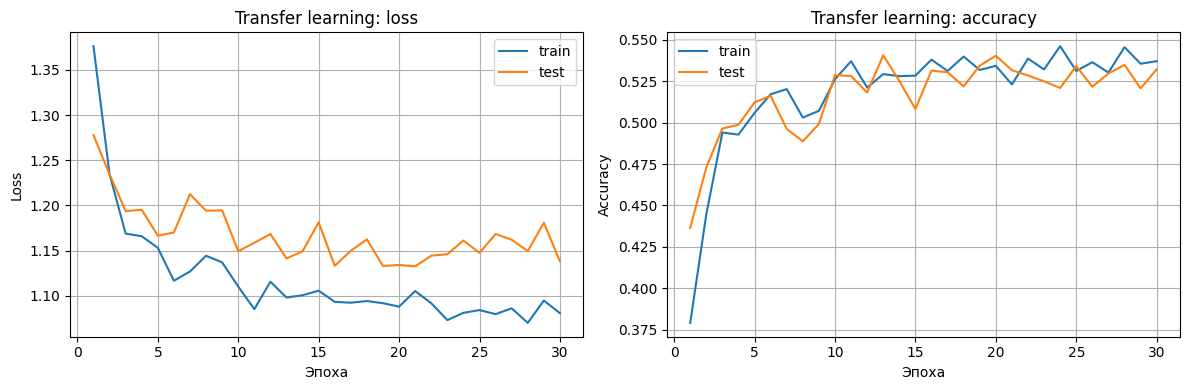

Итоговая точность TL: train=0.5372, test=0.5323


In [12]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [13]:
tl_comment = """
По результатам обучения видно, что transfer learning модель начинает обучаться
достаточно быстро: уже к 5 эпохе test accuracy превышает 0.51, а максимальное
значение около 0.54 достигается примерно на 13–20 эпохах.

После этого качество практически перестаёт улучшаться и начинает колебаться
около одного уровня. Train accuracy остаётся лишь немного выше test accuracy,
поэтому признаков сильного переобучения не наблюдается.

При этом обучение выглядит довольно нестабильным: на некоторых эпохах test
accuracy немного падает, а затем снова растёт. Это может быть связано с
небольшим размером выборки и тем, что обучается только последний слой модели.

В целом 30 эпох оказались достаточными, так как после первых 15–20 эпох
заметного улучшения уже не происходит. Для дальнейшего повышения качества можно
попробовать частично разморозить более глубокие слои ResNet18 или уменьшить learning rate.
"""
print(tl_comment)


По результатам обучения видно, что transfer learning модель начинает обучаться 
достаточно быстро: уже к 5 эпохе test accuracy превышает 0.51, а максимальное 
значение около 0.54 достигается примерно на 13–20 эпохах.

После этого качество практически перестаёт улучшаться и начинает колебаться 
около одного уровня. Train accuracy остаётся лишь немного выше test accuracy,
поэтому признаков сильного переобучения не наблюдается.

При этом обучение выглядит довольно нестабильным: на некоторых эпохах test 
accuracy немного падает, а затем снова растёт. Это может быть связано с 
небольшим размером выборки и тем, что обучается только последний слой модели.

В целом 30 эпох оказались достаточными, так как после первых 15–20 эпох
заметного улучшения уже не происходит. Для дальнейшего повышения качества можно 
попробовать частично разморозить более глубокие слои ResNet18 или уменьшить learning rate.



## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [14]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/30: train_loss=1.4259, train_acc=0.3822, test_loss=1.2419, test_acc=0.4655
[Scratch] Эпоха 2/30: train_loss=1.1632, train_acc=0.4984, test_loss=1.1689, test_acc=0.5115
[Scratch] Эпоха 3/30: train_loss=1.0961, train_acc=0.5337, test_loss=1.1724, test_acc=0.5152
[Scratch] Эпоха 4/30: train_loss=1.0503, train_acc=0.5544, test_loss=1.1144, test_acc=0.5440
[Scratch] Эпоха 5/30: train_loss=1.0115, train_acc=0.5822, test_loss=1.0822, test_acc=0.5505
[Scratch] Эпоха 6/30: train_loss=0.9874, train_acc=0.5994, test_loss=1.0231, test_acc=0.5760
[Scratch] Эпоха 7/30: train_loss=0.9490, train_acc=0.6006, test_loss=1.0294, test_acc=0.5867
[Scratch] Эпоха 8/30: train_loss=0.9258, train_acc=0.6191, test_loss=1.9279, test_acc=0.4748
[Scratch] Эпоха 9/30: train_loss=0.8882, train_acc=0.6369, test_loss=1.0171, test_acc=0.5855
[Scratch] Эпоха 10/30: train_loss=0.8913, train_acc=0.6312, test_loss=0.9880, test_acc=0.6018
[Scratch] Эпоха 11/30: train_loss=0.8682, train_acc=0.6450, test_loss

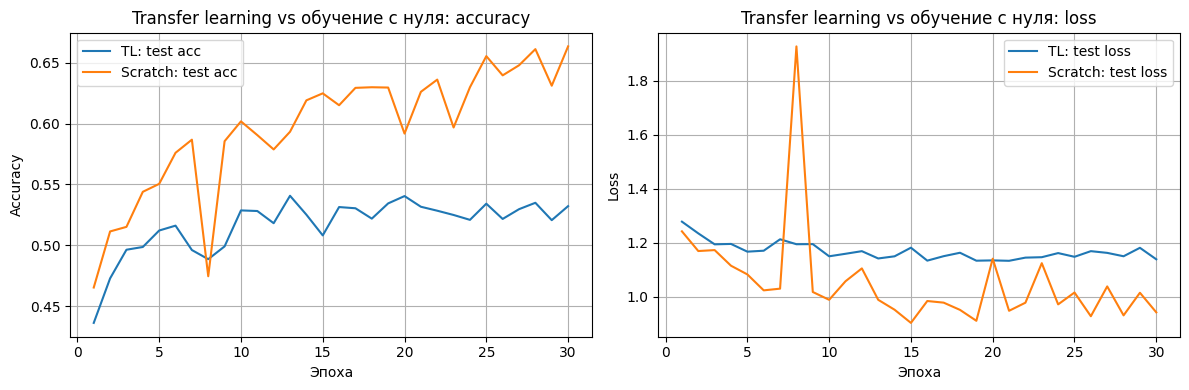

Финальная test accuracy (TL)     : 0.5323
Финальная test accuracy (Scratch): 0.6633


In [15]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [ ]:
comparison_comment = """
По результатам экспериментов модель, обученная с нуля, показала более высокую итоговую точность,
чем transfer learning с замороженными слоями. Финальная test accuracy для t
ransfer learning составила 0.5323, а для scratch-модели — 0.6633.

Transfer learning действительно быстрее начинал обучение: уже на первых эпохах
test accuracy приблизилась к 0.50. Однако затем качество почти перестало расти
и вышло на плато.

Модель, обучаемая с нуля, обучалась медленнее, но продолжала постепенно улучшать
качество на протяжении почти всех эпох. После 10–15 эпох она начала заметно
превосходить transfer learning.

Сильного переобучения ни у одной из моделей не наблюдалось, так как разрыв между
train и test accuracy оставался умеренным. При этом у scratch-модели иногда
возникали скачки test loss, но общая тенденция обучения оставалась положительной.

Результаты частично разошлись с моими ожиданиями. Я предполагала, что transfer
learning покажет более высокое качество, но в данном случае заморозка почти
всей ResNet18ограничила адаптацию модели к CIFAR-10.

Главный вывод для меня — transfer learning помогает быстрее стартовать,
но обучение с нуля может дать лучший итоговый результат, если модели хватает
эпох и данных для обучения.
"""
print(comparison_comment)

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать.
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах?

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`.
Что происходит с пространственным размером картинки по мере прохождения через слои сети?
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [ ]:
star_answer = """
Предобученная ResNet18 обучалась на датасете ImageNet,
где изображения имеют размер примерно 224×224 пикселя.
В CIFAR-10 изображения намного меньше — всего 32×32.

Архитектура ResNet18 содержит несколько слоёв свёртки и pooling,
которые постепенно уменьшают пространственный размер изображения.
Для маленьких изображений CIFAR-10 это становится проблемой:
после нескольких downsampling-операций карта признаков становится слишком маленькой,
и сеть теряет значительную часть полезной информации.

В результате замороженные ранние слои ResNet18, настроенные под большие
изображения ImageNet, не могут эффективно извлекать признаки из маленьких
картинок CIFAR-10. Поэтому transfer learning быстро выходит на плато
и показывает относительно низкую точность.

Одним из способов решения проблемы является увеличение размера изображений
перед подачей в сеть. Тогда структура ResNet18 начинает работать более корректно,
так как пространственные размеры признаков уменьшаются не так агрессивно.

Также можно разморозить часть последних сверточных блоков
или изменить архитектуру сети под маленькие изображения.
"""
print(star_answer)

In [11]:
# Новый preprocessing для ResNet18
train_transform_big = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=8),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform_big = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Загружаем CIFAR-10 заново
full_train_big = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform_big
)

full_test_big = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform_big
)

# Подмножества
train_subset_big = subset_by_classes(
    full_train_big,
    selected_class_indices,
    max_per_class=800
)

test_subset_big = subset_by_classes(
    full_test_big,
    selected_class_indices,
    max_per_class=None
)

train_loader_big = DataLoader(
    train_subset_big,
    batch_size=64,
    shuffle=True
)

test_loader_big = DataLoader(
    test_subset_big,
    batch_size=64,
    shuffle=False
)

# Загружаем ResNet18
better_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Замораживаем слои
for param in better_model.parameters():
    param.requires_grad = False

# Меняем классификатор
better_model.fc = nn.Linear(
    better_model.fc.in_features,
    num_target_classes
)

better_model = better_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_better = torch.optim.Adam(
    better_model.fc.parameters(),
    lr=1e-3
)

# История обучения
history_better = {
    "train_acc": [],
    "test_acc": []
}

num_epochs_better = 10

# Обучение
for epoch in range(1, num_epochs_better + 1):

    train_loss, train_acc = train_one_epoch_tl(
        better_model,
        train_loader_big,
        optimizer_better,
        criterion,
        device
    )

    test_loss, test_acc = evaluate_tl(
        better_model,
        test_loader_big,
        criterion,
        device
    )

    history_better["train_acc"].append(train_acc)
    history_better["test_acc"].append(test_acc)

    print(
        f"[Improved TL] Эпоха {epoch}/{num_epochs_better}: "
        f"train_acc={train_acc:.4f}, "
        f"test_acc={test_acc:.4f}"
    )

print(
    f"\nФинальная test accuracy improved TL: "
    f"{history_better['test_acc'][-1]:.4f}"
)

[Improved TL] Эпоха 1/10: train_acc=0.5825, test_acc=0.7540
[Improved TL] Эпоха 2/10: train_acc=0.7634, test_acc=0.7785
[Improved TL] Эпоха 3/10: train_acc=0.7841, test_acc=0.7682
[Improved TL] Эпоха 4/10: train_acc=0.7934, test_acc=0.7953


KeyboardInterrupt: 

In [13]:
final_star_answer = """
После изменения preprocessing качество transfer learning заметно улучшилось уже
на самых первых эпохах. Если раньше замороженная ResNet18 показывала test accuracy
около 0.53 даже после 30 эпох, то после увеличения размера изображений до 224×224
модель получила test accuracy около 0.75 уже на 1 эпохе.

Далее качество продолжило расти: на 2 эпохе test accuracy достигла 0.7785,
а на 4 эпохе — примерно 0.7953. Это подтверждает, что основной проблемой была
не сама ResNet18, а несоответствие между архитектурой сети и слишком маленькими
изображениями CIFAR-10.

После изменения размера изображений предобученные признаки ImageNet стали
использоваться намного эффективнее, поэтому transfer learning начал работать
значительно лучше и быстрее выходить на высокую точность.
"""
print(final_star_answer)


После изменения preprocessing качество transfer learning заметно улучшилось уже 
на самых первых эпохах. Если раньше замороженная ResNet18 показывала test accuracy 
около 0.53 даже после 30 эпох, то после увеличения размера изображений до 224×224 
модель получила test accuracy около 0.75 уже на 1 эпохе.

Далее качество продолжило расти: на 2 эпохе test accuracy достигла 0.7785,
а на 4 эпохе — примерно 0.7953. Это подтверждает, что основной проблемой была
не сама ResNet18, а несоответствие между архитектурой сети и слишком маленькими
изображениями CIFAR-10.

После изменения размера изображений предобученные признаки ImageNet стали
использоваться намного эффективнее, поэтому transfer learning начал работать
значительно лучше и быстрее выходить на высокую точность.



## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [12]:
final_summary = """
После этой лабораторной я поняла, что transfer learning особенно полезен,
когда данных мало и нужно быстро получить адекватное качество без долгого
обучения сети с нуля. Предобученные модели уже содержат полезные признаки,
поэтому часто достаточно заменить и дообучить только последние слои.

Однако важно учитывать, насколько новая задача похожа на исходный датасет
предобучения. В моём эксперименте оказалось, что маленькие изображения CIFAR-10
плохо подходят для стандартной ResNet18 без дополнительной адаптации.

Если данных достаточно много или изображения сильно отличаются от ImageNet,
имеет смысл обучать модель с нуля или хотя бы размораживать часть сверточных
слоёв. Это позволяет сети лучше подстроиться под новую задачу.

Для себя я сделала вывод, что разумный стартовый вариант —
использовать предобученную модель, маленький learning rate,
замораживать большую часть слоёв и сначала обучать только классификатор.
Если качество быстро выходит на плато, стоит попробовать resize изображений,
частичное размораживание сети или более длительное дообучение.
"""
print(final_summary)


После этой лабораторной я поняла, что transfer learning особенно полезен,
когда данных мало и нужно быстро получить адекватное качество без долгого
обучения сети с нуля. Предобученные модели уже содержат полезные признаки,
поэтому часто достаточно заменить и дообучить только последние слои.

Однако важно учитывать, насколько новая задача похожа на исходный датасет
предобучения. В моём эксперименте оказалось, что маленькие изображения CIFAR-10
плохо подходят для стандартной ResNet18 без дополнительной адаптации.

Если данных достаточно много или изображения сильно отличаются от ImageNet,
имеет смысл обучать модель с нуля или хотя бы размораживать часть сверточных
слоёв. Это позволяет сети лучше подстроиться под новую задачу.

Для себя я сделала вывод, что разумный стартовый вариант —
использовать предобученную модель, маленький learning rate,
замораживать большую часть слоёв и сначала обучать только классификатор.
Если качество быстро выходит на плато, стоит попробовать resize изображе